In [37]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../../Github/Project_banking-fraud-analytics-dashboard-ml-risk/1_Cleaned_Dataset/clean_fraud_df.csv", header=0, index_col=0)

In [38]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["transaction_hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M", errors="coerce").dt.hour
df["transaction_day"] = df["transaction_date"].dt.day
df["transaction_month"] = df["transaction_date"].dt.month
df["transaction_dayofweek"] = df["transaction_date"].dt.dayofweek


In [39]:
df["fraud_label"] = df["fraud_label"].map({"Normal": 0, "Fraud": 1})

yes_no_cols = [
    "is_international_transaction",
    "is_new_merchant",
    "unusual_time_transaction"
]

for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

drop_cols = [
    "customer_id",
    "device_id",
    "ip_address",
    "transaction_time",
    "transaction_date"
]

df = df.drop(columns=drop_cols, errors="ignore")
df

,transaction_amount_in_million,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,card_type,account_balance_in_million,daily_transaction_count,...,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label,Country_x,Country_y,transaction_hour,transaction_day,transaction_month,transaction_dayofweek
customer_id,,,,,,,,,,,,,,,,,,,,,
24239.0,6.0,POS,97028.0,ATM,singapore,lahore,466.0,Credit,30.0,4.0,...,0.0,0,1.0,0,Singapore,Pakistan,10,8,3,5
77250.0,9.0,ATM,27515.0,ATM,singapore,lahore,215.0,Credit,4.0,4.0,...,1.0,0,1.0,0,Singapore,Pakistan,19,17,1,4
34294.0,3.0,POS,13810.0,Electronics,faisalabad,faisalabad,216.0,Debit,38.0,5.0,...,0.0,1,1.0,0,Pakistan,Pakistan,10,30,4,2
92041.0,1.0,Online,10501.0,Grocery,london,karachi,408.0,Debit,22.0,6.0,...,2.0,1,1.0,0,United Kingdom,Pakistan,14,21,2,4
71578.0,1.0,Online,53569.0,Electronics,singapore,islamabad,209.0,Debit,10.0,3.0,...,1.0,0,1.0,0,Singapore,Pakistan,4,11,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87401.0,4.0,POS,13857.0,Clothing,faisalabad,islamabad,571.0,Credit,34.0,1.0,...,1.0,0,0.0,1,Pakistan,Pakistan,18,9,2,6
65425.0,4.0,Online,25552.0,Electronics,faisalabad,multan,433.0,Credit,4.0,4.0,...,2.0,0,0.0,0,Pakistan,Pakistan,21,12,3,2
14318.0,9.0,Online,41771.0,Electronics,singapore,lahore,161.0,Debit,21.0,5.0,...,0.0,0,1.0,1,Singapore,Pakistan,11,4,3,1


In [40]:
#only run code once, otherwise more and more indexes will be added to the DF
df = df.reset_index()
#df

In [41]:
#df = df.drop(["index", "customer_id", "unusual_time_transaction", "is_new_merchant", "is_international_transaction"], axis=1)
df = df.drop(["customer_id"], axis=1)
df

,transaction_amount_in_million,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,card_type,account_balance_in_million,daily_transaction_count,...,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label,Country_x,Country_y,transaction_hour,transaction_day,transaction_month,transaction_dayofweek
0,6.0,POS,97028.0,ATM,singapore,lahore,466.0,Credit,30.0,4.0,...,0.0,0,1.0,0,Singapore,Pakistan,10,8,3,5
1,9.0,ATM,27515.0,ATM,singapore,lahore,215.0,Credit,4.0,4.0,...,1.0,0,1.0,0,Singapore,Pakistan,19,17,1,4
2,3.0,POS,13810.0,Electronics,faisalabad,faisalabad,216.0,Debit,38.0,5.0,...,0.0,1,1.0,0,Pakistan,Pakistan,10,30,4,2
3,1.0,Online,10501.0,Grocery,london,karachi,408.0,Debit,22.0,6.0,...,2.0,1,1.0,0,United Kingdom,Pakistan,14,21,2,4
4,1.0,Online,53569.0,Electronics,singapore,islamabad,209.0,Debit,10.0,3.0,...,1.0,0,1.0,0,Singapore,Pakistan,4,11,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49848,4.0,POS,13857.0,Clothing,faisalabad,islamabad,571.0,Credit,34.0,1.0,...,1.0,0,0.0,1,Pakistan,Pakistan,18,9,2,6
49849,4.0,Online,25552.0,Electronics,faisalabad,multan,433.0,Credit,4.0,4.0,...,2.0,0,0.0,0,Pakistan,Pakistan,21,12,3,2
49850,9.0,Online,41771.0,Electronics,singapore,lahore,161.0,Debit,21.0,5.0,...,0.0,0,1.0,1,Singapore,Pakistan,11,4,3,1
49851,1.0,Online,72485.0,Clothing,bangkok,karachi,317.0,Credit,39.0,3.0,...,0.0,0,1.0,0,Thailand,Pakistan,8,25,3,1


In [42]:
#Step 4: Split data - Train-Test Split
from sklearn.model_selection import train_test_split


X = df.drop(columns=["fraud_label"])
y = df["fraud_label"]
#print(x.head(1))
#print(y.head(1))


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train target ratio:")
print(y_train.value_counts(normalize=True))
print("Test target ration:")
print(y_test.value_counts(normalize=True))

Train target ratio:
fraud_label
0    0.951507
1    0.048493
Name: proportion, dtype: float64
Test target ration:
fraud_label
0    0.95156
1    0.04844
Name: proportion, dtype: float64


In [43]:
#Step 6: Building a preprocessing (separating numerical from categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [44]:
#Train a baseline model with class weights

              precision    recall  f1-score   support

           0       0.96      0.63      0.76      9488
           1       0.06      0.51      0.11       483

    accuracy                           0.62      9971
   macro avg       0.51      0.57      0.44      9971
weighted avg       0.92      0.62      0.73      9971

ROC-AUC: 0.6089027351537433
PR-AUC: 0.0677761347320994


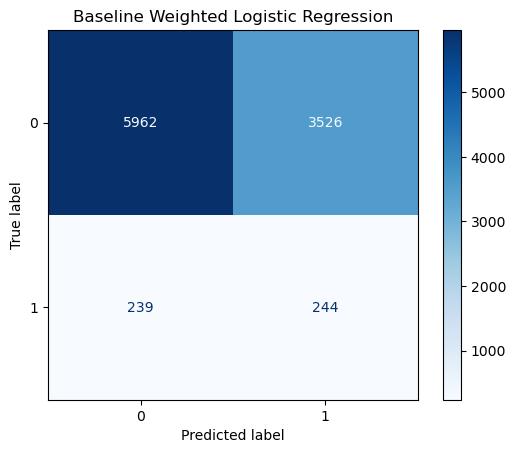

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
# Removed pos_label parameter - these functions will automatically detect the positive class
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Baseline Weighted Logistic Regression")
plt.savefig("../4_Datshboards_\_Visualisations/Weighted Logistic Regression", bbox_inches="tight")
plt.show()

#Explanatioin: The weighted logistic regression performed better for the fraud class because it predicted some positives. 
#It found 244 fraud cases, but it also produced many false positives, which is why its recall is 0.51 while its precision is 
#only 0.06

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9488
           1       0.00      0.00      0.00       483

    accuracy                           0.95      9971
   macro avg       0.48      0.50      0.49      9971
weighted avg       0.91      0.95      0.93      9971

ROC-AUC: 0.5770981499132389
PR-AUC: 0.06044926893833812


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


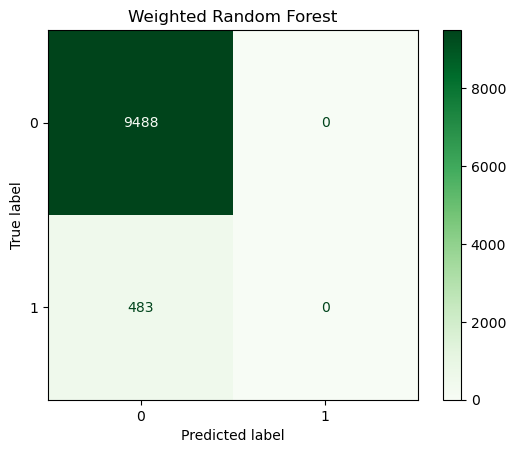

In [48]:
#tree model with class weights

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Greens")
plt.title("Weighted Random Forest")
plt.savefig("../4_Datshboards_\_Visualisations/Weighted Random Forest", bbox_inches="tight")
plt.show()


#Interpretation of the results: The weighted random forest did not predict any fraud cases, 
#so it has zero recall and zero precision for class 1. That means it is not useful for fraud detection in its current form, 
#even though its accuracy looks high because the dataset is imbalanced.

              precision    recall  f1-score   support

           0       0.96      0.62      0.76      9488
           1       0.07      0.52      0.12       483

    accuracy                           0.62      9971
   macro avg       0.51      0.57      0.44      9971
weighted avg       0.92      0.62      0.72      9971

ROC-AUC: 0.6092782776282301
PR-AUC: 0.06924599015301242


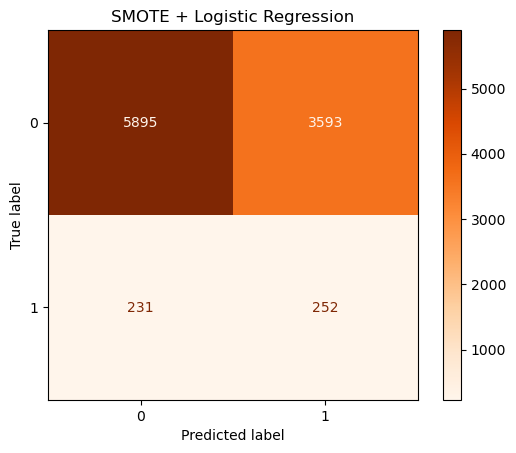

In [50]:
#SMOTE on training

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

smote_model.fit(X_train, y_train)

y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote))
print("PR-AUC:", average_precision_score(y_test, y_proba_smote))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap="Oranges")
plt.title("SMOTE + Logistic Regression")
plt.savefig("../4_Datshboards_\_Visualisations/SMOT", bbox_inches="tight")
plt.show()




    threshold  precision    recall        f1
0        0.10   0.067251  0.047619  0.055758
1        0.15   0.100000  0.002070  0.004057
2        0.20   0.000000  0.000000  0.000000
3        0.25   0.000000  0.000000  0.000000
4        0.30   0.000000  0.000000  0.000000
5        0.35   0.000000  0.000000  0.000000
6        0.40   0.000000  0.000000  0.000000
7        0.45   0.000000  0.000000  0.000000
8        0.50   0.000000  0.000000  0.000000
9        0.55   0.000000  0.000000  0.000000
10       0.60   0.000000  0.000000  0.000000
11       0.65   0.000000  0.000000  0.000000
12       0.70   0.000000  0.000000  0.000000
13       0.75   0.000000  0.000000  0.000000
14       0.80   0.000000  0.000000  0.000000
15       0.85   0.000000  0.000000  0.000000
16       0.90   0.000000  0.000000  0.000000


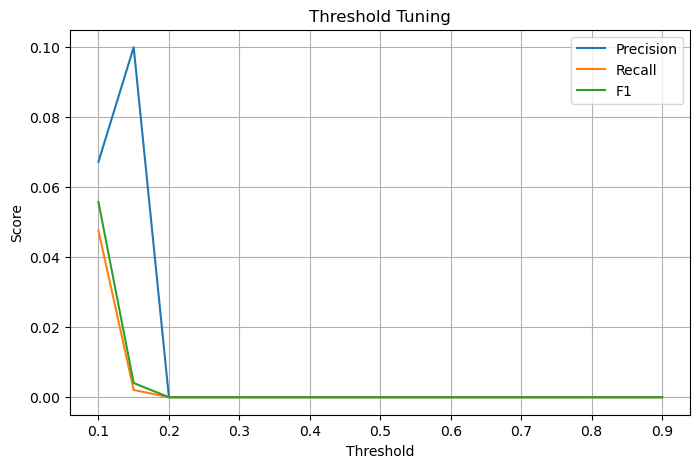

In [52]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    preds = (y_proba_rf >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
print(threshold_df)

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid(True)
plt.savefig("../4_Datshboards_\_Visualisations/Threshold Tuning", bbox_inches="tight")
plt.show()


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)
y_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]


In [54]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

smote_logreg_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_logreg_model.fit(X_train, y_train)
y_pred_smote = smote_logreg_model.predict(X_test)
y_proba_smote = smote_logreg_model.predict_proba(X_test)[:, 1]


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score


In [58]:
with open("logreg_model.pkl", "rb") as f:
    loaded_logreg = pickle.load(f)

with open("smote_logreg_model.pkl", "rb") as f:
    loaded_smote = pickle.load(f)
